In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.widgets import Slider
import time
import json
import warnings
from glob import glob
%matplotlib widget
from tqdm.notebook import tqdm
from scipy.special import iv as mod_bessel #modified bessel function
import os

In [3]:
class System(): #system class is contains all necessary methods for simulations
    default_q_on = 1e-1
    default_q_off = 1e-1 
    default_l0 = 1
    default_k = 1e2
    default_gamma = 1
    default_dt = 1e-3
    default_T = 1
    default_kB = 1
    default_eps = 1e-16
    rng = np.random.default_rng()
    
    def __init__(self, num_elements, pos_init, bonds_init, conn_matrix, q_on = default_q_on, q_off = default_q_off,
                 l0 = default_l0, k = default_k, gamma = default_gamma, dt = default_dt, T = default_T,
                 kB = default_kB, eps = default_eps):
        #setting up initial state
        self.bonds_init = bonds_init.copy()
        self.bonds = bonds_init.copy()
        self.bonds_hist = []
        self.pos_init = pos_init.copy()
        self.pos = pos_init.copy()
        self.pos_hist = []
        self.time_init = 0
        self.time = self.time_init
        self.time_hist = []
        self.connectivity = conn_matrix
        self.num_elements = num_elements
        self.dimensions = np.shape(pos_init)[-1]
        
        #setting up params: 
        self.q_on = q_on
        self.q_off = q_off
        if isinstance(l0, int) or isinstance(l0, float):
            l0 = l0*np.ones((num_elements,num_elements))
        l0 = l0.tolist()
        self.l0 = l0
        self.k = k
        self.gamma = gamma
        self.dt = dt
        self.T = T
        self.kB = kB
        self.eps = eps
        
        #run variables 
        self.num_steps = None 
        self.sample_rate = None
        self.diffusion_constant = None
        self.simulation_duration = None
        
        #other
        self.time_slider = None
        
        self.sanity_check()

    def sanity_check(self): #checks if parameter and initial states are consistent
        if len(self.bonds) != self.num_elements: 
            print("Bond array size does not match number of elements") 
        if len(self.pos_init) != self.num_elements: 
            print("Position array size does not match number of elements") 
        if np.shape(self.connectivity)[0] != self.num_elements or np.shape(self.connectivity)[-1] != self.num_elements:
            print("Connectivity array size does not match number of elements")
    
    def step(self): #takes one discrete time step forward
        #update pos
        pos_steps = []
        for i in range(len(self.bonds)):
            if self.bonds[i] == 0: 
                res_list = []
                for j in range(len(self.bonds)): 
                    if j != i:  
                        res_list.append(self.connectivity[i,j]*(self.pos[j]-self.pos[i])/\
                                    (np.linalg.norm(self.pos[j]-self.pos[i])+self.eps)*\
                                    (np.linalg.norm(self.pos[j]-self.pos[i])-self.l0[i][j]))
                pos_steps.append(self.k/self.gamma*sum(res_list)*self.dt+\
                                 self.rng.normal(scale = np.sqrt(2*self.kB*self.T*self.dt/self.gamma),
                                                 size = self.dimensions))
            elif self.bonds[i] == 1:
                pos_steps.append(np.zeros(shape = self.dimensions, dtype = "float"))
        
        #update positions simultaneously
        for i in range(len(self.bonds)):
            self.pos[i] += pos_steps[i]
  
        #update bonds
        has_updated = False
        for i in range(len(self.bonds)): 
            if self.bonds[i] == 0 and has_updated == False: 
                if self.rng.random() < self.q_on*self.dt: 
                    self.bonds[i] = 1
                    has_updated = True
            if self.bonds[i] == 1 and has_updated == False: 
                if self.rng.random() < self.q_off*self.dt: 
                    self.bonds[i] = 0
                    has_updated = True
            
        #update time 
        self.time += self.dt
        
        
    def run(self, num_steps, sample_rate = 0): #runs the system for certain number of steps, samples at interval
        start_time = time.time()
        num_steps = int(num_steps)
        self.num_steps = num_steps
        sample_rate = int(sample_rate)
        self.sample_rate = sample_rate
        for i in range(num_steps+1): 
            if sample_rate != 0: 
                if i%sample_rate == 0: 
                    self.pos_hist += [self.pos.copy()]
                    self.bonds_hist += [self.bonds.copy()]
                    self.time_hist += [self.time]
            self.step()
        end_time = time.time()
        self.simulation_duration = end_time-start_time
        
    
    
    def plot_hist(self): #plots the configurations of the systems with a time slider (only works in 2d+1d)
        if self.dimensions in [1,2]: #check for appropriate number of dimensions 
            num = 0
            fig, ax = plt.subplots()
            plt.subplots_adjust(bottom=0.1, left = 0.1)  # Make room for the slider
            poshist = np.array(self.pos_hist.copy())
            bondshist = np.array(self.bonds_hist.copy())
            cmap_dict = {1:"red", 0:"green"}
            colors_bonds = [cmap_dict[item] for item in bondshist[0]]
            
            if self.dimensions == 1:
                poshist = np.append(poshist,np.zeros(np.shape(poshist)),axis = 2) #modify array to plotted

            for i in range(0, self.num_elements-1): #plotting the data
                for j in range(i+1, self.num_elements): 
                    if self.connectivity[i,j] != 0: 
                        ax.plot(poshist[num][[i,j],0], poshist[num][[i,j],1], ls = "dashed", color = "grey" , lw = 2)           
            ax.scatter(poshist[num][:,0], poshist[num][:,1], marker = "o", s = 100, c = colors_bonds)
            ax.grid() 
            ax.set_aspect("equal")
            ax.set_xlim(-3,3)
            ax.set_ylim(-3,3)

            #implementing the slider
            axtime = fig.add_axes([0.10, 0.00, 0.8, 0.03])
            self.time_slider = Slider(axtime, "hist", valmin = 0,
                                      valmax = len(self.pos_hist)-1, valinit = 0, valstep = 1)
        
        else: 
            warnings.warn(f"The plot_hist functions only supports 1d and 2d, your dimension is {self.dimension}",UserWarning)
        
        def update(val): 
            time_index = int(self.time_slider.val)
            xmin,xmax = ax.get_xlim()
            ymin,ymax = ax.get_ylim()
            ax.clear()
            ax.set_xlim(xmin,xmax)
            ax.set_ylim(ymin,ymax)
            ax.set_aspect("equal")
            colors_bonds = [cmap_dict[item] for item in bondshist[time_index]]
            ax.scatter(poshist[time_index][:,0], poshist[time_index][:,1], marker = "o", s = 100, c = colors_bonds)
            ax.grid()
            for i in range(0, self.num_elements-1):
                for j in range(i+1, self.num_elements): 
                    if self.connectivity[i,j] != 0: 
                        ax.plot(poshist[time_index][[i,j],0], 
                                      poshist[time_index][[i,j],1], ls = "dashed", color = "grey" , lw = 2)
            fig.canvas.draw_idle()
        self.time_slider.on_changed(update)
        plt.show()
     
    
    def calculate_diffusion_const(self): #calculates the diffusion coefficient at each sampled position
        center_hist = np.mean(self.pos_hist, axis = 1)
        center_norm_squared_hist = np.mean(np.array(center_hist)**2, axis = 1)
        self.diffusion_constant = (1/2*np.array(np.divide(center_norm_squared_hist[1:],self.time_hist[1:]))).tolist()
        self.diffusion_constant.insert(0,0) #set first value to zero in order to avoid problems
        
    def write_hist(self, foldername = "", create_folders = False): #writes the sampled states and params to .json
        #serializing data
        def serialize(value):
            if isinstance(value, np.ndarray):
                return value.tolist()  # Convert numpy arrays to lists
            elif isinstance(value, list):
                return [serialize(item) for item in value]  # Recursively handle items in lists
            elif isinstance(value, dict):
                return {k: serialize(v) for k, v in value.items()}  # Recursively handle values in dicts
            elif isinstance(value, (int, float, str)):
                return value  # Directly serializable types
            else:
                warnings.warn(f"Converting an unsupported type ({type(value)}) to string for serialization", UserWarning)
                return str(value)  # Fallback: convert other types to string
        
        attributes = vars(self)
        #organizing the data into categories:
        categorized_attrs = {
        "Initial_Parameters": {
            "num_elements": self.num_elements,
            "pos_init": serialize(self.pos_init),
            "bonds_init": serialize(self.bonds_init),
            "connectivity": serialize(self.connectivity),
        },
        "System_Parameters": {
            "q_on": self.q_on,
            "q_off": self.q_off,
            "l0": self.l0,
            "k": self.k,
            "gamma": self.gamma,
            "Temp": self.T,
            "kB": self.kB,
            "eps": self.eps,
            "dt" : self.dt,
        },
        "Run_Variables": {
            "num_steps" : self.num_steps,
            "sample_rate" : self.sample_rate,
            "final_time" : self.dt*self.num_steps,
            "simulation_duration": self.simulation_duration
        },    
        "Sampled_States": {
            "pos_hist": serialize(self.pos_hist),
            "bonds_hist": serialize(self.bonds_hist),
            "time_hist": serialize(self.time_hist),
        },
        "Results": {
            "diffusion_constant": self.diffusion_constant
        }
    }
    
        current_time = time.localtime()
        datetime_str = time.strftime("%d%m%Y_%H%M%S", current_time)
        if create_folders == False: 
            with open("run_hist/"+foldername+"/"+datetime_str+".json","w") as file:
                json.dump(categorized_attrs, file, indent = 4)
        
        else: 
            os.makedirs(os.path.dirname("run_hist/"+foldername+"/"+datetime_str+".json"), exist_ok=True)
            with open("run_hist/"+foldername+"/"+datetime_str+".json","w") as file: 
                json.dump(categorized_attrs, file, indent = 4)
    
    def reset(self): #resets the system
        self.bonds = self.bonds_init
        self.pos = self.pos_init
        self.time = self.time_init
        self.bonds_hist = []
        self.pos_hist = []
        self.time_hist = []

In [4]:
def pos_init_setup(num_elems, l_0 = 1): #returns a 2d ring pos distr. with CoM at 0 and neighbors distanced l0
    if num_elems == 1: 
        pos_init = np.array([[0,0]], dtype = "float")
    else: 
        r_circ= l_0/(2*np.sin(np.pi/num_elems)) #radius of inscribing circle 
        phi_int = 2*np.pi/num_elems
        pos_init = []
        for n in range(num_elems):
            pos_init.append([r_circ*np.cos(n*phi_int),
                                  r_circ*np.sin(n*phi_int)])
        pos_init = np.array(pos_init, dtype = "float")
    return pos_init

def pos_init_setup_chain(num_elems, l_0 = 1): 
    spacer = np.arange(1,num_elems+1)-np.mean(np.arange(1,num_elems+1))
    pos_init = []
    for space in spacer: 
        pos_init.append([l_0*space,0])
    pos_init = np.array(pos_init, dtype = "float")
    return pos_init

def bonds_init_setup(num_elems, q_on, q_off):
    bonds_init = []
    for k in range(num_elems): 
        rng = np.random.default_rng()
        if q_on == 0 and q_off == 0: 
            bonds_init.append(False)
        else: 
            if rng.random() < q_off/(q_on+q_off): 
                bonds_init.append(False)
            else: 
                bonds_init.append(True)
    return np.array(bonds_init, dtype = "bool")
            

def connectivity_setup_ring(num_elems): #sets up the default connectivity matrix for ring,  
    arr = np.zeros((num_elems,num_elems))
    for i in range(num_elems-1):
        arr[i,i+1] = 1
        arr[i+1,i] = 1
    arr[0,num_elems-1] = 1
    arr[num_elems-1,0] = 1
    return arr

def connectivity_setup_chain(num_elems): #sets up the connectivity matrix for chain
    arr = np.zeros((num_elems,num_elems))
    for i in range(num_elems-1):
        arr[i,i+1] = 1
        arr[i+1,i] = 1
    return arr

def connectivity_setup_fully(num_elems): #sets up the reinforced ring connectivity matrix 
    return np.ones((num_elems, num_elems))

def natural_rest_lengths(pos_init): #calculates the distances between particles as rest length:
    num_elems = len(pos_init)
    arr = np.zeros((num_elems,num_elems))
    for i in range(num_elems): 
        for j in range(num_elems): 
            arr[i,j] = np.linalg.norm(pos_init[i]-pos_init[j])
    return arr

### Example system simulation with visualization

  0%|          | 0/1 [00:00<?, ?it/s]

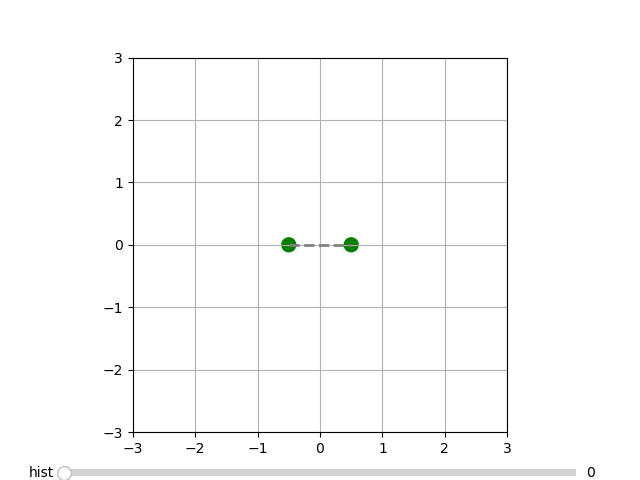

In [5]:
#example function call
num_elems = 2
pos_init = np.array([[-1/2], [1/2]], dtype = "float")
conn_matrix = connectivity_setup_chain(num_elems)
l0 = natural_rest_lengths(pos_init)
q_on = 0
q_off = 0
for i in tqdm(range(1)):
    bonds_init = bonds_init_setup(num_elems,q_on,q_off)
    sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off, l0 = l0, dt = 1e-4)
    sys.run(1e3,1e2)
    sys.calculate_diffusion_const()
    sys.plot_hist()
    sys.write_hist("2part_1d/no_binding")


### Presentation Animation 

In [ ]:
#Plotting a nice visualization for illustrative purposes for e.g. presentation

for num in range(len(sys.time_hist)):
    fig, ax = plt.subplots()
    poshist = np.array(sys.pos_hist.copy())
    bondshist = np.array(sys.bonds_hist.copy())
    cmap_dict = {1:"red", 0:"green"}
    colors_bonds = [cmap_dict[item] for item in bondshist[num]]

    if sys.dimensions == 1:
        poshist = np.append(poshist,np.zeros(np.shape(poshist)),axis = 2) #modify array to plotted

    for i in range(0, sys.num_elements-1): #plotting the data
        for j in range(i+1, sys.num_elements): 
            if sys.connectivity[i,j] != 0: 
                ax.plot(poshist[num][[i,j],0], poshist[num][[i,j],1], ls = "dashed", color = "grey" , lw = 2)           
    ax.scatter(poshist[num][:,0], poshist[num][:,1], marker = "o", s = 100, c = colors_bonds)
    ax.grid() 
    ax.set_aspect("equal")
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    plt.savefig("images/animation/frame"+str(num))
    plt.close("all")


### Simulation Examples

Simulation of two particles in one dimension

In [ ]:
#different qon for 2part1d
num_elems = 2
for q_on in np.linspace(1,110,10):
    q_off = q_on
    pos_init = np.array([[-1/2], [1/2]], dtype = "float")
    conn_matrix = connectivity_setup_chain(num_elems)
    for n in tqdm(range(300)): 
        bonds_init = bonds_init_setup(num_elems, q_on, q_off)
        sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off)
        sys.run(1e4,1e3)
        sys.calculate_diffusion_const()
        foldername = "2part_1d_variable_qon/qon"+str(q_on)
        sys.write_hist(foldername = foldername, create_folders = True)

In [ ]:
#different qon for 2part1d
num_elems = 2
for q_on in np.linspace(110,300,10):
    q_off = q_on
    pos_init = np.array([[-1/2], [1/2]], dtype = "float")
    conn_matrix = connectivity_setup_chain(num_elems)
    for n in tqdm(range(100)): 
        bonds_init = bonds_init_setup(num_elems, q_on, q_off)
        sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off)
        sys.run(1e4,1e3)
        sys.calculate_diffusion_const()
        foldername = "2part_1d_variable_qon/qon"+str(q_on)
        sys.write_hist(foldername = foldername, create_folders = True)

Simulation of rings with various elements, 2 dimensions

In [ ]:
#ring simulation
for num_elems in [4]:
    for q_on in [1]: 
        for q_off in [0.2,1]:
            for k in range(120,300,20):
                pos_init = pos_init_setup(num_elems)
                conn_matrix = connectivity_setup_ring(num_elems)
                for n in tqdm(range(50)): 
                    bonds_init = bonds_init_setup(num_elems, q_on, q_off)
                    sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off, k = k)
                    sys.run(5e4,1e3)
                    sys.calculate_diffusion_const()
                    foldername = "variable_k_4p/rings"+"k"+str(k)+"qon"+str(q_on)+"qoff"+str(q_off)
                    sys.write_hist(foldername = foldername, create_folders = True)

Simulation of fully connected particle network with different elements, 2 dimensions

In [ ]:
#fully connected simulation
for num_elems in [4]:
    for q_on in [1]: 
        for q_off in [0.2,1]:
            for k in range(80,110,10):
                pos_init = pos_init_setup(num_elems)
                conn_matrix = connectivity_setup_fully(num_elems)
                l0 = natural_rest_lengths(pos_init)
                for n in tqdm(range(50)): 
                    bonds_init = bonds_init_setup(num_elems, q_on, q_off)
                    sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off, l0 = l0, k = k)
                    sys.run(1e5,1e3)
                    sys.calculate_diffusion_const()
                    foldername = "variable_k_4p/reinforced_rings"+"k"+str(k)+"qon"+str(q_on)+"qoff"+str(q_off)
                    sys.write_hist(foldername = foldername, create_folders = True)

In [ ]:
#fully connected simulation
for num_elems in [4]:
    for q_on in [1]: 
        for q_off in [0.2,1]:
            for k in range(120,300,20):
                pos_init = pos_init_setup(num_elems)
                conn_matrix = connectivity_setup_fully(num_elems)
                l0 = natural_rest_lengths(pos_init)
                for n in tqdm(range(50)): 
                    bonds_init = bonds_init_setup(num_elems, q_on, q_off)
                    sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off, l0 = l0, k = k)
                    sys.run(5e4,1e3)
                    sys.calculate_diffusion_const()
                    foldername = "variable_k_4p/reinforced_rings"+"k"+str(k)+"qon"+str(q_on)+"qoff"+str(q_off)
                    sys.write_hist(foldername = foldername, create_folders = True)

In [ ]:
#fully connected simulation
for num_elems in [4]:
    for q_on in [1]: 
        for q_off in [0.2,1]:
            for k in range(1000,2100,200):
                pos_init = pos_init_setup(num_elems)
                conn_matrix = connectivity_setup_fully(num_elems)
                l0 = natural_rest_lengths(pos_init)
                for n in tqdm(range(50)): 
                    bonds_init = bonds_init_setup(num_elems, q_on, q_off)
                    sys = System(num_elems, pos_init, bonds_init, conn_matrix, q_on = q_on, q_off = q_off, l0 = l0, k = k)
                    sys.run(5e4,1e3)
                    sys.calculate_diffusion_const()
                    foldername = "variable_k_4p/reinforced_rings"+"k"+str(k)+"qon"+str(q_on)+"qoff"+str(q_off)
                    sys.write_hist(foldername = foldername, create_folders = True)